# Prepared by: Safal Sapkota
# AI Coursework: Lab 2 (Search Algorithms)
# Date: March 1, 2026

## **Linear Regression**

**Linear Regression** is a statistical and machine learning method used to model the relationship between a **dependent variable** and one or more **independent variables** by fitting a straight line to the data.

The objective of linear regression is to determine the best-fitting line that minimizes the error between **actual values** and **predicted values**.

---

## **Why We Need Linear Regression**

- It provides a **simple and interpretable** approach to prediction
- It helps in understanding how changes in input variables affect the output
- It is widely used for **trend analysis** and **forecasting**
- It serves as a **baseline model** for comparing more advanced machine learning algorithms
- Its transparency makes it suitable for **learning**, **analysis**, and **reporting**


# **Single Variable Linear Regression**

i.e., One input variable/feature and one output variable/target

So, Our model: $$ y = wX+b$$

Where, 
- X : input to the model
- y : output of the model for the given input X
- w,b : parameters for best fit and are referred as $\theta$ for ease of use. 


The graph for the task is shown as below: 
![linear-regression-figure](linereg.png)
Here, 
- x-axis: input/features
- y-axis: target/output/labels (value to be predicted)


**Definition**:

- `Linear regression` is a simple approach to supervised learning. It assumes that the dependence of 𝑌 on 𝑥1, 𝑥2,…,$𝑥_𝑛$ is linear. 

- `Linear regression` is a fundamental statistical and machine learning technique used to model the relationship between a dependent (target) variable and one or more independent (predictor) variables. The goal is to **fit a linear model to the data that best predicts the target variable**.

# **Task-1: Simple Linear Regression (Single Feature)**

## **DATA RETRIEVAL AND COLLECTION**

In [1]:
import pandas as pd

data = pd.read_csv("./housing.csv")
print("Data loaded successfully!")
    
    # Display basic information
print(f"\nDataset Shape: {data.shape}")
print(f"   - Rows (samples): {data.shape[0]}")
print(f"   - Columns (features): {data.shape[1]}")
    
print(f"\nColumn Names:")
for i, col in enumerate(data.columns, 0):
        print(f"   {i}. {col}")
    
    # Display first few rows
display(data.head(10))    

Data loaded successfully!

Dataset Shape: (20640, 10)
   - Rows (samples): 20640
   - Columns (features): 10

Column Names:
   0. longitude
   1. latitude
   2. housing_median_age
   3. total_rooms
   4. total_bedrooms
   5. population
   6. households
   7. median_income
   8. median_house_value
   9. ocean_proximity


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


## **DATA CLEANING**

In [2]:

# Check for missing values
print("\n(i) Missing Values Count:")
print(data.isnull().sum())


(i) Missing Values Count:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [3]:
# Verify data types
print("\n(ii) Data Types:")
print(data.dtypes)


(ii) Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


In [4]:
print("\n(iii)Handle missing values")
initial_rows = len(data)

# Remove rows with missing values in key columns
data_cleaned = data.dropna(subset=['housing_median_age', 'median_house_value'])

rows_removed = initial_rows - len(data_cleaned)
print(f"Rows removed: {rows_removed}")
print(f"Remaining rows: {len(data_cleaned)}")



(iii)Handle missing values
Rows removed: 0
Remaining rows: 20640


## **FEATURE DESIGN**

Feature (X) shape: (20640, 1)
Label (Y) shape: (20640,)


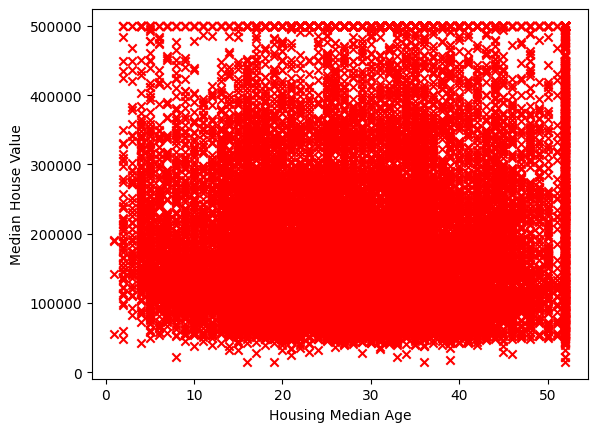

In [5]:
X = data[['housing_median_age']]   # Feature
Y = data['median_house_value']     # Target
print("Feature (X) shape:", X.shape)
print("Label (Y) shape:", Y.shape)

import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter(X, Y, marker='x', color='red')
plt.xlabel('Housing Median Age')
plt.ylabel('Median House Value')
plt.show()

# **Why This Feature Was Chosen?**

---

## **i. Clarity and Simplicity**

**Housing age** is a straightforward and easily comprehensible attribute.

- It allows for **smooth analysis**
- It effectively illustrates the basic working of **simple linear regression**
- No additional **technical complexity** is introduced

---

## **ii. Practical Significance**

The **age of housing units** has a strong influence on **real estate pricing** and **market trends**:

- **Recently built homes** usually offer:
  - Modern layouts
  - Improved construction quality
  - Energy-efficient technologies

- **Older homes** in mature neighborhoods may possess:
  - Cultural or historical importance
  - Higher land value

- **Property age** can also represent:
  - Physical wear over time
  - Long-term growth in area value

---

## **iii. Quantitative Nature**

**Median housing age** is a **continuous numerical variable**, making it directly suitable for **linear regression models**.

- No data transformation is required
- No feature encoding is necessary

---

## **iv. Learning Effectiveness**

Using a **single predictor variable** enables:

- Clear visualization in **two-dimensional space**
- Better understanding of core regression concepts such as:
  - **Slope** (model coefficient)
  - **Intercept** (constant term)
  - **Linear relationship** between input **`X`** and output **`Y`**


## **ALGORITHM SELECTION**

# **Chosen Algorithm: Linear Regression**

**Linear Regression** was selected as the predictive approach for this task based on the following considerations:

---

## **1. Numerical Output Variable**

The model aims to estimate **`median_house_value`**, which is a **real-valued quantitative variable** representing housing prices.

- **Linear Regression** is well-suited for predicting **continuous numerical outcomes**
- Appropriate when the target variable lies on a **real number scale**

---

## **2. Single Predictor Variable**

In this case, **`housing_median_age`** is the **only independent (explanatory) variable** used.

- Linear Regression performs effectively when modeling the relationship between:
  - **One independent variable**
  - **One dependent variable**

---

## **3. Straightforward Relationship Representation**

The objective is to analyze how **housing age** influences **property value**.

This relationship is expressed using the linear equation:

$$
\mathbf{y = mx + c}
$$

### **Where:**

- **`y`** → Estimated house price  
- **`x`** → Median housing age  
- **`m`** → Rate of change of price with respect to age  
- **`c`** → Constant term (intercept)

This equation represents a **linear association** between the variables.

---

## **4. Model Transparency**

**Linear Regression** provides **clear and interpretable parameters**.

- The coefficient **`m`** directly indicates:
  - The **change in house price** for a **one-year increase** in housing age

This simplicity makes the model suitable for:

- **Learning**
- **Interpretation**
- **Academic and technical reporting**

---

## **5. Reference Model**

**Linear Regression** acts as a **baseline (reference) model**.

It enables:

- Comparison with models using **multiple features**
- Evaluation against **more advanced machine learning techniques**

This provides a solid **benchmark** for future improvements.


In [6]:
import numpy as np

def compute_cost(X, y, theta):
    return np.sum(np.square(np.matmul(X, theta) - y)) / (2 * len(y))

def normalize(X):
    mu = np.mean(X, axis=0)      # mean of each column
    sigma = np.std(X, axis=0)    # std of each column
    X_norm = (X - mu) / sigma
    return X_norm

def gradient_descent(x, y, iterations, alpha, *, theta = None):
    if theta is None:
        theta = np.zeros(x.shape[1])
    # this gives the no of value same as len(x) since it gives row for a np
    m = len(y)
    for i in range(iterations):
        gradient = np.matmul(x.T, np.matmul(x, theta) - y) / m
        # it seems you can alse do this
        # gradient = x.T @ (x @ theta - y) / m theese days
        if np.linalg.norm(gradient) <= 1e-6:
            break
        theta = theta - (alpha * gradient)
    return theta



## **LOSS FUNCTION SELECTION**

In [7]:
X = data[['housing_median_age']].values.flatten()  # Adjust column name
Y = data['median_house_value'].values

theta = np.zeros(2)
X_with_bias = np.column_stack((np.ones(len(X)), X))
y = Y

cost = compute_cost(X_with_bias, y, theta)
print('theta:', theta)
print('cost:', cost)

theta: [0. 0.]
cost: 28052415994.936264


## **Data split**

In [8]:
from sklearn.model_selection import train_test_split

X = data['housing_median_age'].values
y = data['median_house_value'].values

# Train–test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add bias term
X_train_b = np.column_stack((np.ones(len(X_train)), X_train))
X_test_b = np.column_stack((np.ones(len(X_test)), X_test))


## **MODEL LEARNING (TRAINING)**

theta: [100146.42318681   3288.78031743]
cost: 7129814599.770212


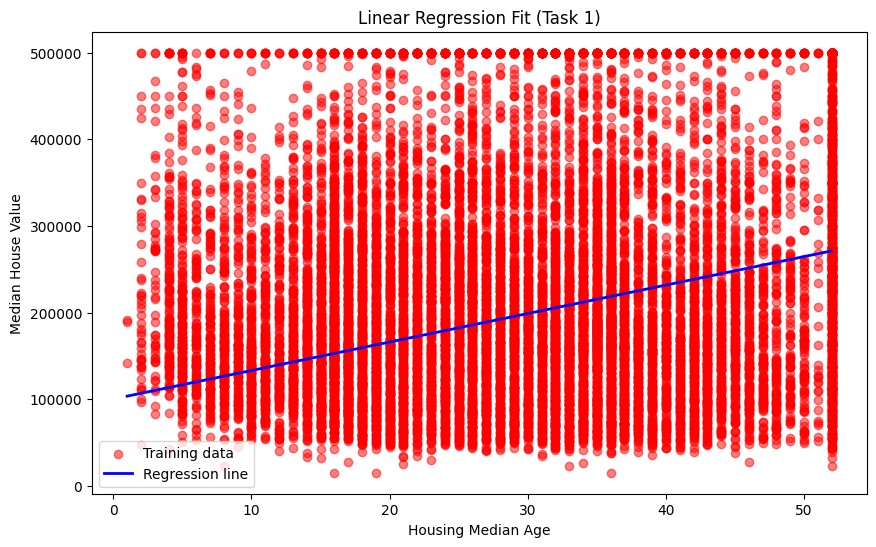

In [9]:


# Gradient descent function
def gradient_descent(X, y, alpha, iterations):
    theta = np.zeros(2)
    m = len(y)
    
    for i in range(iterations):
        t0 = theta[0] - (alpha / m) * np.sum(np.dot(X, theta) - y)
        t1 = theta[1] - (alpha / m) * np.sum((np.dot(X, theta) - y) * X[:,1])
        theta = np.array([t0, t1])
    
    return theta

# Run gradient descent
iterations = 5000
alpha = 0.001
theta = gradient_descent(X_train_b, y_train, alpha, iterations)  # ← Use X_with_bias here!
cost = compute_cost(X_train_b, y_train, theta)  # ← And here!

print("theta:", theta)
print('cost:', cost)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='red', alpha=0.5, label='Training data')

x_vals = np.linspace(X.min(), X.max(), 100)
y_vals = theta[0] + theta[1] * x_vals

plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='Regression line')
plt.xlabel('Housing Median Age')
plt.ylabel('Median House Value')
plt.legend()
plt.title('Linear Regression Fit (Task 1)')
plt.show()

In [10]:
# Re-train Task 1 model (single feature)
theta = gradient_descent(X_train_b, y_train, alpha=0.001, iterations=5000)


## **Evaluation**

In [11]:
# Predict using test data
y_pred = X_test_b @ theta

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
print("Test Mean Squared Error:", mse)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


Test Mean Squared Error: 13843811843.797167
R² Score: -0.056449709493075595


The high MSE indicates that predictions made using only housing median age deviate substantially from the true house values.
Negative R² score means the model performs slightly worse than a baseline model that always predicts the average house value.

## **Intrepretation of Single Value linear regression**

> What does the coefficient represent?
> - The Coefficient represents the slope of the line

> What does the intercept mean in this context?
> - The intercept usually is the value when all values are zero and can equal to the mean if the given value is mean centered.


# **Task-2: Multiple Linear Regression (All Features)**


In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
data = pd.read_csv("./housing.csv")
print(f"Dataset Shape: {data.shape}")
print(f"   - Rows (samples): {data.shape[0]}")
print(f"   - Columns (features): {data.shape[1]}")

print(f"\nColumn Names:")
for i, col in enumerate(data.columns, 0):
    print(f"   {i}. {col}")

# Display first few rows
print("\nFirst 10 rows:")
display(data.head(10))

Dataset Shape: (20640, 10)
   - Rows (samples): 20640
   - Columns (features): 10

Column Names:
   0. longitude
   1. latitude
   2. housing_median_age
   3. total_rooms
   4. total_bedrooms
   5. population
   6. households
   7. median_income
   8. median_house_value
   9. ocean_proximity

First 10 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [14]:

# Check for missing values
print("\n(i) Missing Values Count:")
print(data.isnull().sum())

# Verify data types
print("\n(ii) Data Types:")
print(data.dtypes)


(i) Missing Values Count:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

(ii) Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


In [15]:
initial_rows = len(data)
# Remove rows with missing values
data_cleaned = data.dropna()
rows_removed = initial_rows - len(data_cleaned)
print(f"\n✓ Rows removed (missing values): {rows_removed}")
print(f"✓ Remaining rows: {len(data_cleaned)}")
print(data_cleaned.isna().values.any())



✓ Rows removed (missing values): 207
✓ Remaining rows: 20433
False


In [16]:
feature_columns = [col for col in data_cleaned.columns if col != 'median_house_value']
print(f"\nFeatures selected: {feature_columns}")
print(f" Number of features: {len(feature_columns)}")

# Prepare X (features) and y (target)
X = data_cleaned[feature_columns].values
y = data_cleaned['median_house_value'].values

print(f"\n✓ Feature matrix (X) shape: {X.shape}")
print(f"✓ Target vector (y) shape: {y.shape}")


Features selected: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
 Number of features: 9

✓ Feature matrix (X) shape: (20433, 9)
✓ Target vector (y) shape: (20433,)


## **Data Splitting**

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# features and target
X = data_cleaned[['housing_median_age','total_rooms','total_bedrooms',
                  'population','households','median_income']].values
y = data_cleaned['median_house_value'].values

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
# compute stats from training set only
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

# normalize
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma


## **Training**

In [19]:
X_train = np.column_stack((np.ones(X_train.shape[0]), X_train))
X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))


In [20]:
def gradient_descent_multi(x, y, iterations, alpha, *, theta = None):
    if theta is None:
        theta = np.zeros(x.shape[1])
    # this gives the no of value same as len(x) since it gives row for a np
    m = len(y)
    for i in range(iterations):
        gradient = np.matmul(x.T, np.matmul(x, theta) - y) / m
        if np.linalg.norm(gradient) <= 1e-6:
            break

        theta = theta - (alpha * gradient)
    return theta

In [21]:
alpha = 0.1
iterations = 10000

theta = gradient_descent_multi(X_train, y_train, iterations, alpha)

print("Learned parameters:", theta)


Learned parameters: [206644.40009788  23655.73892701 -42819.18985032  43824.83799112
 -37975.22681838  43965.42934851  90521.50694755]


Multiple linear regression extends simple linear regression by incorporating multiple input features to better capture relationships affecting house prices.
Mean Squared Error was used as the loss function for consistency with Task 1.

In [22]:
X = data_cleaned[['housing_median_age','total_rooms','total_bedrooms',
          'population','households','median_income']].values
Y = data_cleaned['median_house_value'].values#.reshape(-1,1)

# normalize
mu = X.mean(axis=0)
sigma = X.std(axis=0)
X = (X - mu) / sigma
print(data_cleaned.isna().values.any())
# add bias
X = np.column_stack((np.ones(X.shape[0]), X))

alpha = 0.1
iteration = 10000
theta = gradient_descent_multi(X, Y, iteration, alpha)

print("predicted weights:", theta)


False
predicted weights: [206864.41315519  23698.7264617  -43121.11968694  42535.16671936
 -40022.83617367  47710.98946874  90685.86264832]


## **Evaluation**

In [23]:
y_pred = X_test @ theta


In [24]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)


Mean Squared Error (MSE): 5858412975.683012
R² Score: 0.5716025208485934


## Which model performs better?

**Multiple Linear Regression (Task 2)** performs significantly better:

- **Lower MSE / RMSE**: More accurate predictions  
- **Higher R² score**: Explains more variance in house prices  

---

## Why does using multiple features help?

- **Captures complexity**: House prices depend on many factors (income, location, size, age)  
- **Reduces unexplained variance**: A single feature leaves much information unused  
- **Better generalization**: The model learns richer patterns from the data  

---

## Which model is easier to interpret?

**Simple Linear Regression (Task 1)** is easier to interpret:

- **One relationship**: Clear understanding of age vs. price  
- **Simple visualization**: Easy to plot and explain  
- **Single coefficient**: Straightforward meaning  

**Multiple Linear Regression** is more powerful, but:

- **Many coefficients**: Harder to understand individual effects  
- **Interaction effects**: Features may correlate with each other  
- **Scaling issues**: Coefficients are not directly comparable  
